In [12]:
import pandas as pd
df = pd.read_csv('../test/genai_questions_809156896092057937.csv')
#df = pd.read_csv('../test/genai_questions_311016922297059474.csv')
print (df.head(10))

questions = df['questions'].to_list()

                                           questions
0  What is the typical failure rate and common fa...
1  What type of sensor data is collected from the...
2  What is the sampling frequency of the sensor d...
3  Are there any specific performance metrics or ...
4  Is there any historical data on past failures ...
5  Are there any specific environmental or operat...
6  Are there any regulatory or safety requirement...
7  Are there any specific communication protocols...
8  Are there any other systems or components that...
9  Are there any specific data preprocessing or f...


0	3.474396144861517
1	4.242640687119286
2	2.6666666666666665
3	4.477215043467819
4	4.587317109255645
5	4.706787243316417
6	4.123105625617661
7	4.4907311951024935
8	4.37880269519857
9	4.37880269519857
10	4.69041575982343
11	4.811252243246881
12	4.913538149119954
13	4.8
14	5.0137741307804005
15	4.314554973040049
16	4.4907311951024935
17	4.587317109255645
18	4.37880269519857
19	4.024922359499621
20	4.526019054848144
21	5.316456139417774
22	4.74692883171144
23	4.381780460041329
24	5.102520385624567
25	4.118438837901865
26	5.11207720338155
27	4.849343154722923
28	4.929503017546495
29	4.74692883171144
30	4.642383454426297
31	5.567764362830022
32	5.028948456749697
33	4.490132550669373
34	4.706787243316417
35	4.72455591261534
36	5.208553758776472
37	5.0137741307804005
38	4.811252243246881
39	5.0137741307804005
40	5.102520385624567
41	5.003702332976757
42	4.286607049870562
43	4.898979485566357
44	4.37880269519857
45	4.6
46	4.587317109255645
47	4.37880269519857
48	4.08248290463863
49	4.618802153

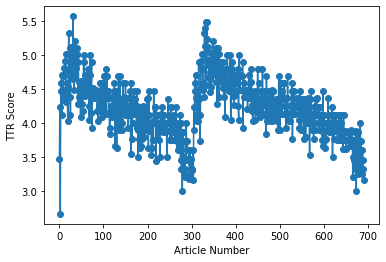

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import nltk as nlp
import matplotlib.pyplot as plt 
import re
from nltk.probability import FreqDist
import math


# List to store the TTR values 
TTR_List=[]
#List to store the ID of the article
Article_Number=[]
for counter in range(len(questions)):
    document = questions[counter]
    #Remove all special characters using this regex 
    document= re.sub(r'[^\w]', ' ', document)
    #Convert Document to Lower Case
    document=document.lower()


    tokens = nlp.word_tokenize(document)
    total_tokens = len(tokens)
    freq_dist = FreqDist(tokens)
    num_types = len(freq_dist)
    normalized_ttr = num_types / math.sqrt(total_tokens)

    TTR = normalized_ttr
    print(str(counter)+"\t"+str(TTR))
    #Append TTR to TTR_List 
    TTR_List.append(TTR)
    #Append counter to Article_Number
    Article_Number.append(counter)

# Draw Scatter Plot of Article_Number vs TTR 
plt.scatter(Article_Number,TTR_List)
# Draw Connecting Line Plot of Article_Number vs TTR
plt.plot(Article_Number,TTR_List)
plt.xlabel("Article Number")
plt.ylabel("TTR Score")
plt.show()


In [15]:
from collections import Counter

def distinct_n(examples, n):
    counter = Counter()
    n_total = 0
    n_distinct = 0
    for example in examples:
        gen = example.split()
        for token in zip(*(gen[i:] for i in range(n))):
            if token not in counter:
                n_distinct += 1
            elif counter[token] == 1:
                n_distinct -= 1
            counter[token] += 1
            n_total += 1
    return n_distinct, n_total

n_distinct, n_total = distinct_n(questions, 1)
print (n_distinct, n_total, n_distinct/n_total)

n_distinct, n_total = distinct_n(questions, 2)
print (n_distinct, n_total, n_distinct/n_total)

n_distinct, n_total = distinct_n(questions, 3)
print (n_distinct, n_total, n_distinct/n_total)

417 14071 0.02963542036813304
1715 13379 0.12818596307646313
3007 12687 0.23701426657208166
